# Introdução ao Projeto de Machine Learning

Este projeto foi desenvolvido com base na atividade proposta pelo SC TEC, onde o objetivo escolher uma base de dados, e desenvolver um pipeline de Machine Learning, para prever uma variável alvo.

A base de dados escolhida foi a **E-Commerce Dataset**, e o alvo que deve ser previsto e a variável **Churn**, onde:

1.   `0` representa clientes que **ficam** na plataforma.
2.   `1` representa clientes que **saem** da plataforma.

## Pre-requisitos

Para conseguir rodar as celulas abaixo no VS Code, será necessario instalar todas as bibliotecas usadas.

No terminal do VS Code, rode o seguinte comando:

`pip install -r requirements.txt`

# Fase 1: Analise Exploratória

Primeiro vamos carregar o nosso dataset, e fazer uma análise exploratória, olhando a sua estrutura, os seus tipos de dados de cada coluna, quantos nulos temos em cada categoria, e etc...

In [8]:
# Antes de iniciarmos, vamos importar as bibliotecas essenciais para essa etapa
# como Pandas, Numpy, e entre outros.
# Importaremos outras conforme for necessárias ao longo da execução

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Começo do projeto:\n")
print(f"{'-'*10} ETAPA 1: Inicio da EAD {'-'*10}")
print("="*50)

print("\nCarregando o arquivo...")

try:
    # Carregar o arquivo csv em um dataframe
    df = pd.read_csv("..\\dataset\\E Commerce Dataset.xlsx - E Comm.csv")
    

    # Teste para ver se o arquivo foi carregado e esta funcionando
    print("\nTeste:")
    print(".head")
    display(df.head(1))

    # Usamos o .tail para ver se o arquivo não foi corrompido durante
    # o carregamento
    print("\nTeste:")
    print(".tail")
    display(df.tail(1))
    print("\nArquivo carregado com sucesso!")

except FileNotFoundError:
    print("Erro: O arquivo 'E Commerce Dataset.xlsx - E Comm.csv' não foi encontrado. Verifique se o caminho do arquivo esta correto.")
except Exception as e:
    print(f"Ocorreu um erro inesperado ao carregar o arquivo: {e}")

Começo do projeto:

---------- ETAPA 1: Inicio da EAD ----------

Carregando o arquivo...

Teste:
.head


,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,160



Teste:
.tail


,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
5629,55630,0,8.0,Mobile Phone,1,15.0,Credit Card,Male,3.0,2,Laptop & Accessory,3,Married,4,0,13.0,2.0,2.0,3.0,169



Arquivo carregado com sucesso!


In [17]:
# Configuração de estilo
sns.set_theme(style="whitegrid")

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['DejaVu Sans' ,'Liberation Sans', 'Arial']

In [12]:
# Com o arquivo carregado, podemos iniciar a analise, ver a estrutura desse dataset,
# como está organizado, os tipos de dados, entre outros

print(f"{'-'*10} INICIANDO A ANALISE {'-'*10}")
print("="*50)
print()

# -- FORMA: Ver quantas linhas e colunas o dataset tem
print("1. Forma do dataset (quantas linhas e colunas):")
print(f"{" "*2}- Linhas: {df.shape[0]}")
print(f"{" "*2}- Colunas: {df.shape[1]}")

print(f"\n{"-"*7}\n")

# -- TIPOS DE DADOS: Ver os tipos de dados de cada coluna,
# assim como quantos nulos cada coluna tem
print("2. Tipos de dados de cada coluna:\n")
print(df.info())

print(f"\n{"-"*7}\n")

# -- PORCENTAGEM DE NULOS: Fazer a porcentagem de nulos de
# cada coluna (junto com o total em número da coluna), assim fica mais
# facil entender o comportamento dos nulos do que só apenas usando .info

print("3. Porcentagem e total de nulos:\n")

# Criamos um DataFrame especifico apenas para exibir a quantidade
# e porcentagem de nulos

# Calculando a porcentagem das colunas
nan_porc = round(( df.isnull().sum() / df.shape[0])*100, 1)
nan_tabela = pd.DataFrame({"Total de Nulos": df.isnull().sum(), "Porcentagem (%)": nan_porc})
nan_tabela = nan_tabela.sort_values(by="Porcentagem (%)", ascending=False)

print(nan_tabela)

print(f"\n{"-"*7}\n")

# -- DUPLICATAS: Verificando a existência de dados duplicados no dataset
total_duplicados = df.duplicated().sum()

print(f"4. Total de linhas duplicadas: {total_duplicados}")

if total_duplicados > 0:
    print("Existem registros duplicados que precisam ser tratados.")
else:
    print("Não foram encontrados registros duplicados.")

print(f"\n{"-"*7}\n")

---------- INICIANDO A ANALISE ----------

1. Forma do dataset (quantas linhas e colunas):
  - Linhas: 5630
  - Colunas: 20

-------

2. Tipos de dados de cada coluna:

<class 'pandas.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   CustomerID                   5630 non-null   int64  
 1   Churn                        5630 non-null   int64  
 2   Tenure                       5366 non-null   float64
 3   PreferredLoginDevice         5630 non-null   str    
 4   CityTier                     5630 non-null   int64  
 5   WarehouseToHome              5379 non-null   float64
 6   PreferredPaymentMode         5630 non-null   str    
 7   Gender                       5630 non-null   str    
 8   HourSpendOnApp               5375 non-null   float64
 9   NumberOfDeviceRegistered     5630 non-null   int64  
 10  PreferedOrderCat             5630 

In [11]:
# -- ESTRUTURA: Olhando a estrutura e formato (.head()) com 7 registros
print("5. Estrutura do dataset:")
display(df.head(7))

print(f"\n{"-"*7}\n")

# -- ESTATISTICA: Como vimos no .info(), temos muitas colunas númericas, portanto, vamos
# tirar as descrições estatísticas das colunas numéricas (media, desvio padrão, etc..)

print("6. Estatísticas do dataset:")
display(df.describe())

print(f"\n{"-"*7}\n")

# -- VALORES ÚNICOS: Ver em todas as colunas, quantas categorias cada coluna tem,
# util para ver as colunas com baixa cardinalidade (pouca variação),
# valores fora do normal, assim como quando fizermos o tratamento e
# a limpeza de algumas colunas

print("7. Numero de valores únicos:")

# Tiramos o 'CustomerID' pois ele tem um registro para cada linha, portanto
# não nos serve para está analise
df_mostrar_unique = df.drop(columns=["CustomerID"])

# Ordenamos em ordem crescente (do maior ao menor)
df_mostrar_unique = df_mostrar_unique.nunique().sort_values(ascending=False)

display(df_mostrar_unique)

print(f"\n{"-"*7}\n")

5. Estrutura do dataset:


,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,160
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,121
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,130
5,50006,1,0.0,Computer,1,22.0,Debit Card,Female,3.0,5,Mobile Phone,5,Single,2,1,22.0,4.0,6.0,7.0,139
6,50007,1,NaN,Phone,3,11.0,Cash on Delivery,Male,2.0,3,Laptop & Accessory,2,Divorced,4,0,14.0,0.0,1.0,0.0,121



-------

6. Estatísticas do dataset:


,CustomerID,Churn,Tenure,CityTier,WarehouseToHome,HourSpendOnApp,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
count,5630.000000,5630.000000,5366.000000,5630.000000,5379.000000,5375.000000,5630.000000,5630.000000,5630.000000,5630.000000,5365.000000,5374.000000,5372.000000,5323.000000,5630.000000
mean,52815.500000,0.168384,10.189899,1.654707,15.639896,2.931535,3.688988,3.066785,4.214032,0.284902,15.707922,1.751023,3.008004,4.543491,177.221492
std,1625.385339,0.374240,8.557241,0.915389,8.531475,0.721926,1.023999,1.380194,2.583586,0.451408,3.675485,1.894621,2.939680,3.654433,49.193869
min,50001.000000,0.000000,0.000000,1.000000,5.000000,0.000000,1.000000,1.000000,1.000000,0.000000,11.000000,0.000000,1.000000,0.000000,0.000000
25%,51408.250000,0.000000,2.000000,1.000000,9.000000,2.000000,3.000000,2.000000,2.000000,0.000000,13.000000,1.000000,1.000000,2.000000,146.000000
50%,52815.500000,0.000000,9.000000,1.000000,14.000000,3.000000,4.000000,3.000000,3.000000,0.000000,15.000000,1.000000,2.000000,3.000000,163.000000
75%,54222.750000,0.000000,16.000000,3.000000,20.000000,3.000000,4.000000,4.000000,6.000000,1.000000,18.000000,2.000000,3.000000,7.000000,196.000000
max,55630.000000,1.000000,61.000000,3.000000,127.000000,5.000000,6.000000,5.000000,22.000000,1.000000,26.000000,16.000000,16.000000,46.000000,325.000000



-------

7. Numero de valores únicos:


CashbackAmount                 220
Tenure                          36
WarehouseToHome                 34
DaySinceLastOrder               22
CouponUsed                      17
OrderCount                      16
OrderAmountHikeFromlastYear     16
NumberOfAddress                 15
PreferredPaymentMode             7
PreferedOrderCat                 6
NumberOfDeviceRegistered         6
HourSpendOnApp                   6
SatisfactionScore                5
MaritalStatus                    3
CityTier                         3
PreferredLoginDevice             3
Complain                         2
Gender                           2
Churn                            2
dtype: int64


-------



### Conclusões Preliminares da Análise Exploratória

1.  **Perfil de Dados Faltantes:**
    *   Temos **7 colunas com valores nulos**, todas em torno de **4.5% a 5.5%**.
    *   Colunas como `Tenure` (tempo de permanência) e `DaySinceLastOrder` são críticas para prever evasão (Churn). Precisaremos decidir entre inputação (pela média/mediana) ou remoção.

2.  **Desequilíbrio de Classes (Churn):**
    *   Observando as estatísticas descritivas (`describe`), a média da coluna `Churn` (que geralmente é 0 ou 1) nos indica a proporção de clientes que saíram. É essencial verificar se a base é balanceada.

3.  **Cardinalidade e Variáveis Categóricas:**
    *   Existem colunas com baixa cardinalidade (como `Gender`, `CityTier`, `PreferredLoginDevice`), que são ótimas candidatas para *One-Hot Encoding*.
    *   `CustomerID` e um identificador único sem valor preditivo estatístico.

4.  **Outliers e Escala:**
    *   A coluna `CashbackAmount` e `OrderAmountHikeFromlastYear` parecem ter escalas bem diferentes. Talvez seja necessário normalizar esses dados futuramente para modelos de Machine Learning.

5.  **Comportamento do Cliente:**
    *   O `SatisfactionScore` varia de 1 a 5. Será interessante cruzar essa nota com a coluna `Complain` para ver a correlação direta com o Churn.

# Gráficos da AED

Com nossa analise preliminar concluída, agora vamos plotar alguns gráficos, para entender melhor as relações dos dados desse dataset, e encontrar padrões ocultos que não podem ser vistos apenas com textos.

 ---------- PLOTANDO GRÁFICOS ---------- 

GRÁFICO 1: Distribuição na coluna 'Churn'


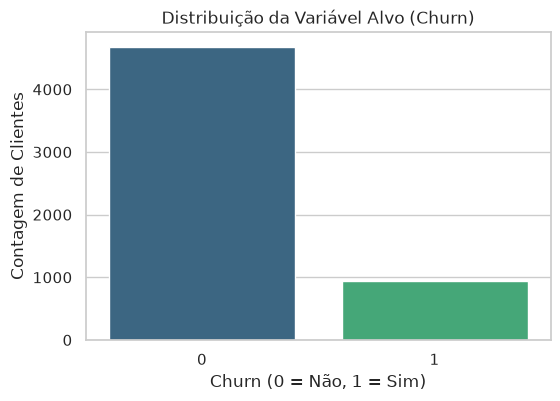

Porcentagem:
0: 83.2%
1: 16.8%

-------



In [18]:
print(f" {'-'*10} PLOTANDO GRÁFICOS {'-'*10} ")
print("="*50)
print()

plt.figure(figsize=(6, 4))

# 1.
# -- CHURN: Count plot para ver se há desbalanceamento
print("GRÁFICO 1: Distribuição na coluna 'Churn'")
sns.countplot(data=df, x='Churn', palette='viridis', hue='Churn', legend=False)
plt.title('Distribuição da Variável Alvo (Churn)')
plt.xlabel('Churn (0 = Não, 1 = Sim)')
plt.ylabel('Contagem de Clientes')
plt.show()

print("Porcentagem:")
print(f"0: { ((df.value_counts('Churn')[0]*100)/df.shape[0]):.1f}%")
print(f"1: { ((df.value_counts('Churn')[1]*100)/df.shape[0]):.1f}%")

print(f"\n{"-"*7}\n")


-------

Gráfico de reclamações:


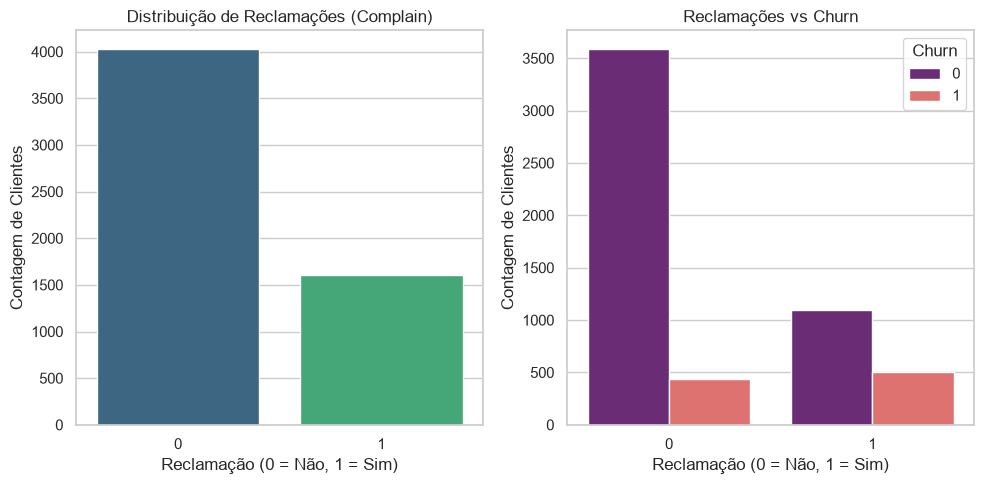


-------



In [19]:
# Grafico de reclamações para ver quantas pessoas reclamaram
# junto com o cruzamento da coluna 'Churn' para ver a proporção
# em relação quem saiu e não saiu

print(f"\n{"-"*7}\n")
print("Gráfico de reclamações:")

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Apenas a distribuição de reclamações
sns.countplot(ax=axes[0], data=df, x='Complain', hue='Complain', palette='viridis', legend=False)
axes[0].set_title('Distribuição de Reclamações (Complain)')
axes[0].set_xlabel('Reclamação (0 = Não, 1 = Sim)')
axes[0].set_ylabel('Contagem de Clientes')

# Reclamações cruzadas com Churn
sns.countplot(ax=axes[1], data=df, x='Complain', hue='Churn', palette='magma')
axes[1].set_title('Reclamações vs Churn')
axes[1].set_xlabel('Reclamação (0 = Não, 1 = Sim)')
axes[1].set_ylabel('Contagem de Clientes')

plt.tight_layout()
plt.show()

print(f"\n{"-"*7}\n")


-------

Gráfico de dispositivos preferidos:


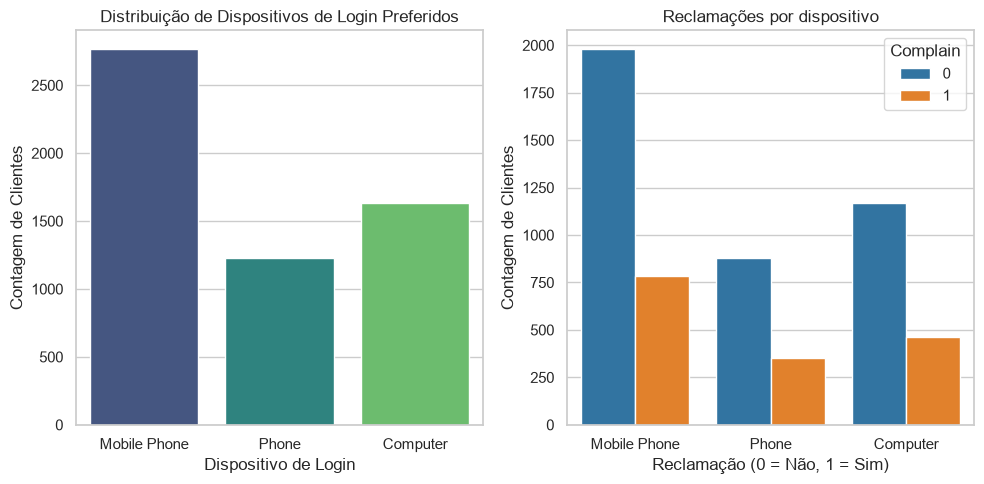


-------



In [20]:
# Grafico de preferência de dispositivo para ver quais dispositivos
# são mais utilizados, junto com o cruzamento de reclamação para
# ver quais tem mais reclamações

print(f"\n{"-"*7}\n")
print("Gráfico de dispositivos preferidos:")

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Contagem de clientes por dispositivo preferido
sns.countplot(ax=axes[0], data=df, x='PreferredLoginDevice', palette='viridis', hue='PreferredLoginDevice', legend=False)
axes[0].set_title('Distribuição de Dispositivos de Login Preferidos')
axes[0].set_xlabel('Dispositivo de Login')
axes[0].set_ylabel('Contagem de Clientes')

# Dispositivos cruzados com reclamações
sns.countplot(ax=axes[1], data=df, x='PreferredLoginDevice', hue='Complain', palette='tab10')
axes[1].set_title('Reclamações por dispositivo')
axes[1].set_xlabel('Reclamação (0 = Não, 1 = Sim)')
axes[1].set_ylabel('Contagem de Clientes')

plt.tight_layout()
plt.show()

print(f"\n{"-"*7}\n")


-------

Gráfico de distribuição da Satisfação:


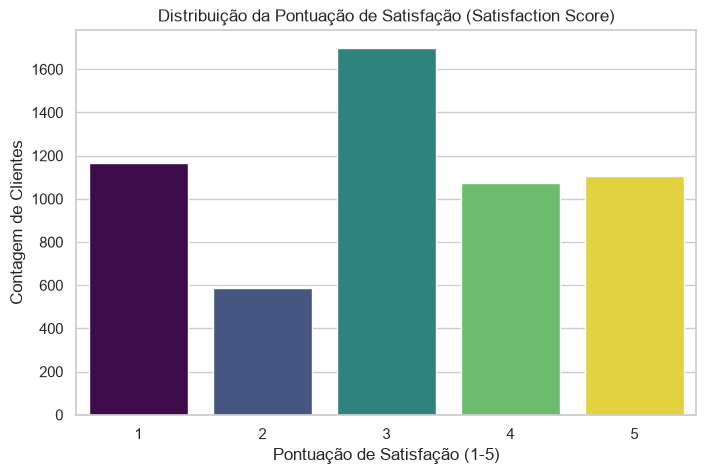

Porcentagem por nota:
Nota 1: 20.7%
Nota 2: 10.4%
Nota 3: 30.2%
Nota 4: 19.1%
Nota 5: 19.7%

-------



In [21]:
print(f"\n{"-"*7}\n")
print("Gráfico de distribuição da Satisfação:")

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='SatisfactionScore', palette='viridis', hue='SatisfactionScore', legend=False)
plt.title('Distribuição da Pontuação de Satisfação (Satisfaction Score)')
plt.xlabel('Pontuação de Satisfação (1-5)')
plt.ylabel('Contagem de Clientes')
plt.show()

print("Porcentagem por nota:")
satisfaction_counts = df['SatisfactionScore'].value_counts(normalize=True) * 100
for score in sorted(satisfaction_counts.index):
    print(f"Nota {score}: {satisfaction_counts[score]:.1f}%")

print(f"\n{"-"*7}\n")


-------

GRÁFICO 2: Distribuição do tempo de permanência:


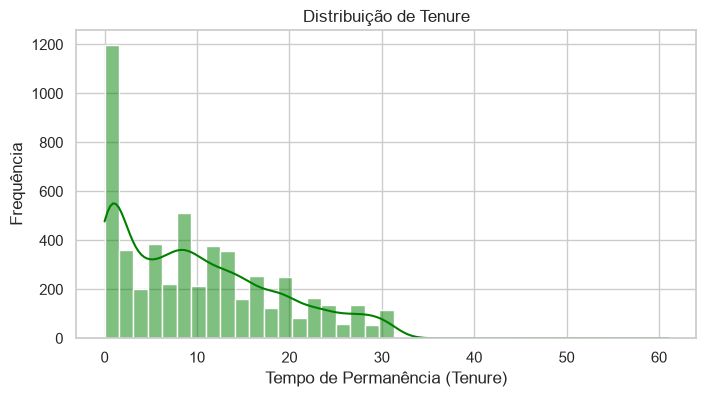


-------



In [22]:
print(f"\n{"-"*7}\n")

#2.
# -- HISTOGRAMAS: Ver a distribuição das variaveis

# Grafico para ver a distribuição em 'Tenure'
print("GRÁFICO 2: Distribuição do tempo de permanência:")

plt.figure(figsize=(8, 4))
sns.histplot(df['Tenure'], kde=True, color='green')
plt.title('Distribuição de Tenure')
plt.xlabel('Tempo de Permanência (Tenure)')
plt.ylabel('Frequência')
plt.show()

print(f"\n{"-"*7}\n")


-------

Gráfico de distribuição de cashback:


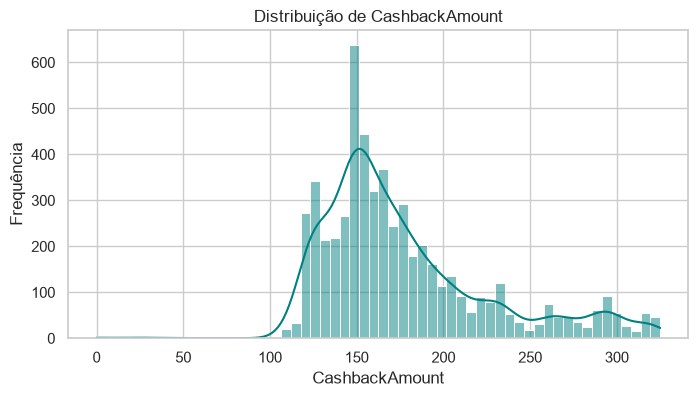


-------



In [23]:
print(f"\n{"-"*7}\n")

# Distribuição de Cashback para identificar valores mais altos
print("Gráfico de distribuição de cashback:")

plt.figure(figsize=(8, 4))
sns.histplot(df['CashbackAmount'], kde=True, color='teal')
plt.title('Distribuição de CashbackAmount')
plt.ylabel('Frequência')
plt.show()

print(f"\n{"-"*7}\n")


-------

Gráfico de distruibuição de dias apos o último pedido:


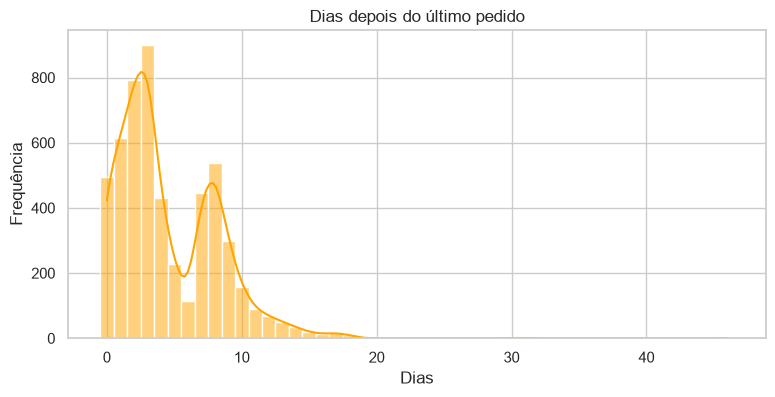


-------



In [24]:
print(f"\n{"-"*7}\n")

# Distribuição de DaySinceLastOrder para ver quantos dias apos o ultimo pedido
plt.figure(figsize=(9, 4))
print("Gráfico de distruibuição de dias apos o último pedido:")

# Usando discrete=True para remover espaços entre barras de valores inteiros
# impedindo das barras serem agrupadas em intervalos de float (1.5, 2.5)
sns.histplot(df['DaySinceLastOrder'], kde=True, color='orange', discrete=True)
plt.title('Dias depois do último pedido')
plt.xlabel('Dias')
plt.ylabel('Frequência')
plt.show()

print(f"\n{"-"*7}\n")


-------

Gráfico de distribuição da distância entre armazém e residência:


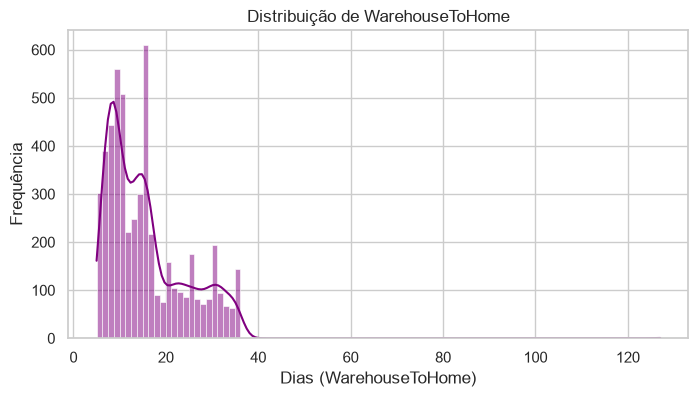


-------



In [25]:
print(f"\n{'-'*7}\n")

# Distribuição de WarehouseToHome para ver qual o prazo de entrega mais comum
print("Gráfico de distribuição da distância entre armazém e residência:")

plt.figure(figsize=(8, 4))
sns.histplot(df['WarehouseToHome'], kde=True, color='purple')
plt.title('Distribuição de WarehouseToHome')
plt.xlabel('Dias (WarehouseToHome)')
plt.ylabel('Frequência')
plt.show()

print(f"\n{'-'*7}\n")


-------

GRÁFICO 3: Outliers do tempo de permanência:


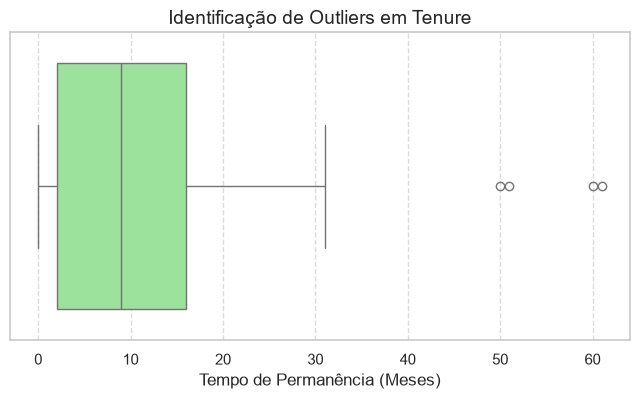


-------



In [26]:
print(f"\n{'-'*7}\n")

#3.
# -- BOXPLOTS: Identificar outliers, quartis, e a mediana
print("GRÁFICO 3: Outliers do tempo de permanência:")

# Visualizando outliers de Tenure
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['Tenure'], color='lightgreen')
plt.title('Identificação de Outliers em Tenure', fontsize=14)
plt.xlabel('Tempo de Permanência (Meses)')
plt.grid(True, axis='x', linestyle='--', alpha=0.7)
plt.show()

print(f"\n{'-'*7}\n")


-------

Gráfico Boxplot de 'DaySinceLastOrder'


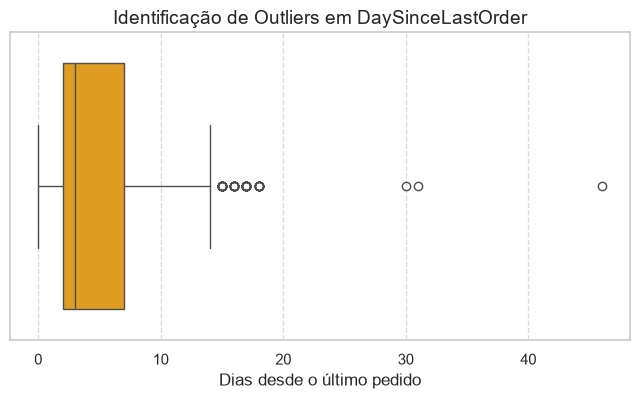


-------



In [27]:
print(f"\n{'-'*7}\n")
print("Gráfico Boxplot de 'DaySinceLastOrder'")

plt.figure(figsize=(8, 4))
sns.boxplot(x=df['DaySinceLastOrder'], color='orange')
plt.title('Identificação de Outliers em DaySinceLastOrder', fontsize=14)
plt.xlabel('Dias desde o último pedido')
plt.grid(True, axis='x', linestyle='--', alpha=0.7)
plt.show()

print(f"\n{'-'*7}\n")


-------

Gráfico Boxplot de 'CashbackAmount'


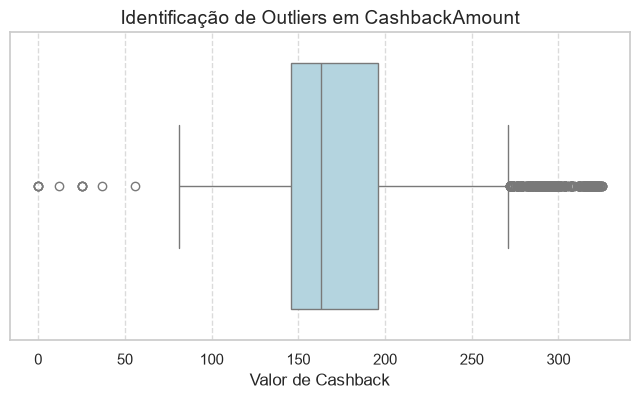


-------



In [28]:
print(f"\n{'-'*7}\n")
print("Gráfico Boxplot de 'CashbackAmount'")

plt.figure(figsize=(8, 4))
sns.boxplot(x=df['CashbackAmount'], color='lightblue')
plt.title('Identificação de Outliers em CashbackAmount', fontsize=14)
plt.xlabel('Valor de Cashback')
plt.grid(True, axis='x', linestyle='--', alpha=0.7)
plt.show()

print(f"\n{'-'*7}\n")

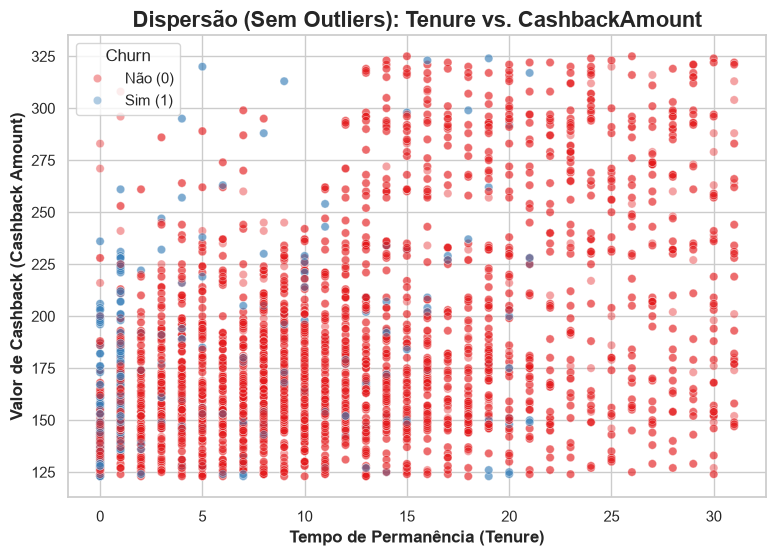

In [29]:
# 4.
# -- SCATTERPLOT: Ver a dispersão de algumas colunas

# Filtrando outliers e embaralhando os dados
df_filtered = df[(df['CashbackAmount'] >= 120) & (df['Tenure'] <= 31)].copy()
df_plot = df_filtered.sample(frac=1, random_state=42)

plt.figure(figsize=(9, 6))

# Plotando o scatter
scatter = sns.scatterplot(data=df_plot, x='Tenure', y='CashbackAmount', hue='Churn', palette='Set1', alpha=0.4)

plt.title('Dispersão (Sem Outliers): Tenure vs. CashbackAmount', fontsize=16, fontweight='bold')
plt.xlabel('Tempo de Permanência (Tenure)', fontweight='bold')
plt.ylabel('Valor de Cashback (Cashback Amount)', fontweight='bold')

handles, labels = scatter.get_legend_handles_labels()
plt.legend(handles, ['Não (0)', 'Sim (1)'], title='Churn')

plt.show()

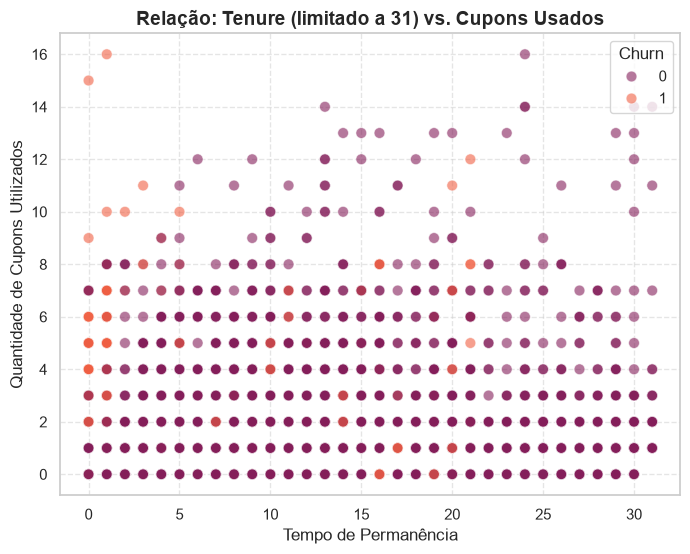

Nova Correlação de Pearson entre Tenure (filtrado) e CouponUsed: 0.13


In [30]:
# Gráfico para ver se a quantidade de cupons usados
# influencia na permanência de um cliente

# Filtrando outliers acima de 31
df_filtered = df[(df['Tenure'] <= 31)].copy()

plt.figure(figsize=(8, 6))
# Usando a paleta 'rocket' e aumentando o tamanho dos pontos (s) para melhor clareza
sns.scatterplot(data=df_filtered, x='Tenure', y='CouponUsed', hue='Churn', palette='rocket', alpha=0.6, s=60)

plt.title('Relação: Tenure (limitado a 31) vs. Cupons Usados', fontsize=14, fontweight='bold')
plt.xlabel('Tempo de Permanência')
plt.ylabel('Quantidade de Cupons Utilizados')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Churn', loc='upper right')
plt.show()

# Recalculando a correlação com os dados tratados
corr_tenure_coupon = df_filtered[['Tenure', 'CouponUsed']].corr().iloc[0,1]
print(f"Nova Correlação de Pearson entre Tenure (filtrado) e CouponUsed: {corr_tenure_coupon:.2f}")

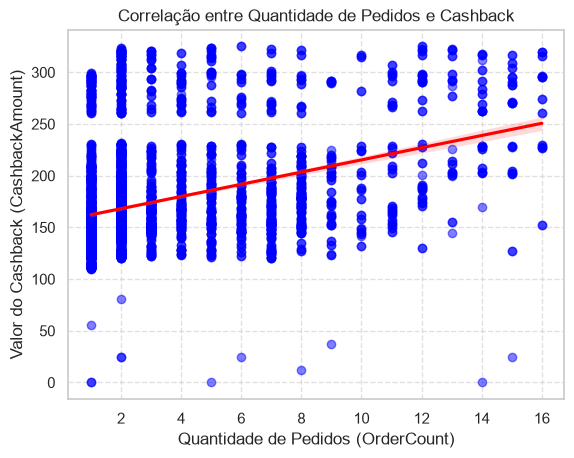

In [31]:
# Gráfico de dispersão com linha de tendência sobre
# quantidade de pedidos e valor de cashback
sns.regplot(data=df, x='OrderCount', y='CashbackAmount',
            scatter_kws={'alpha':0.5, 'color':'blue'},
            line_kws={'color':'red'})

plt.title('Correlação entre Quantidade de Pedidos e Cashback')
plt.xlabel('Quantidade de Pedidos (OrderCount)')
plt.ylabel('Valor do Cashback (CashbackAmount)')
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()


-------

GRÁFICO 5: Mapa de correlação entre as colunas númericas


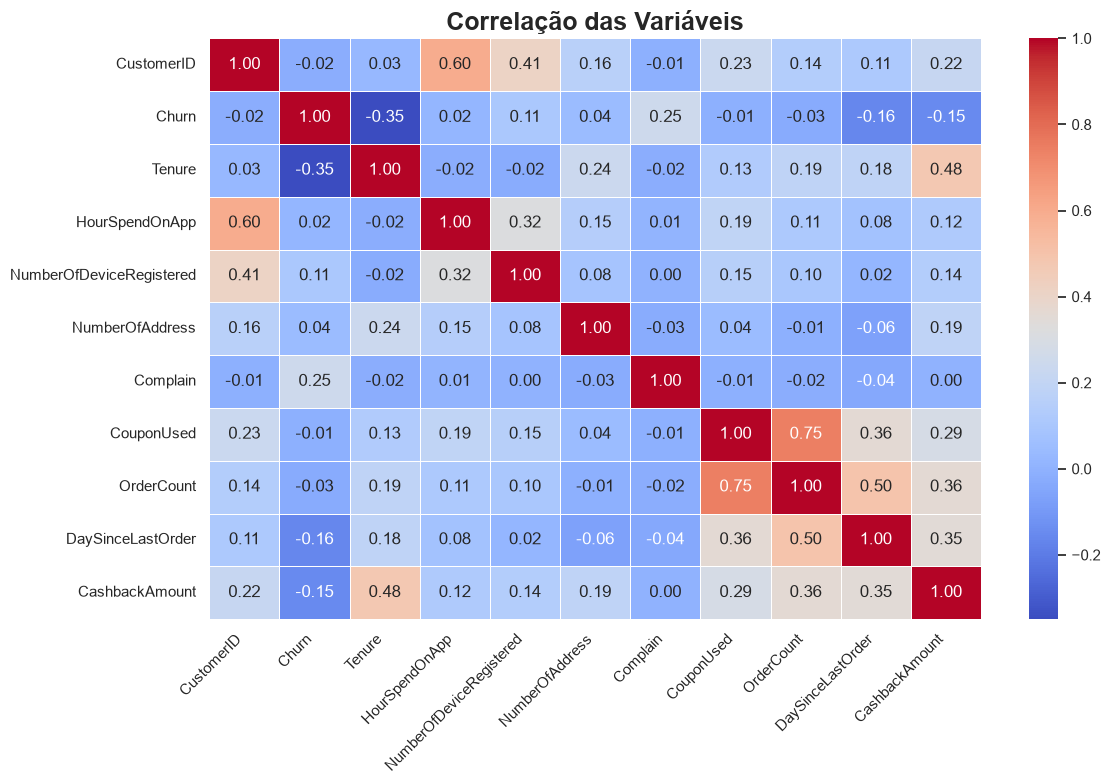


-------



In [32]:
# 5.
# -- MAPA DE CORRELAÇÃO: Ver a correlação entre as colunas númericas

print(f"\n{"-"*7}\n")
print("GRÁFICO 5: Mapa de correlação entre as colunas númericas")

plt.figure(figsize=(12, 8))

# Filtrando para pegar APENAS colunas com números (int, float) ou booleanos (True/False)
df_num = df.select_dtypes(include=['number', 'bool'])

# Retirando algumas colunas para faciliar a visualização
df_num = df_num.drop(columns=['CityTier', 'OrderAmountHikeFromlastYear', 'SatisfactionScore', 'WarehouseToHome'])

# Calculando a correlação no novo DataFrame numérico (com Pearson)
ax = sns.heatmap(df_num.corr(method='pearson'), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

plt.title('Correlação das Variáveis', fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\n{"-"*7}\n")


-------

GRÁFICO 6: Cruzamentos e relações
'Tenure' vs 'Churn', e 'Churn' vs 'Complain'


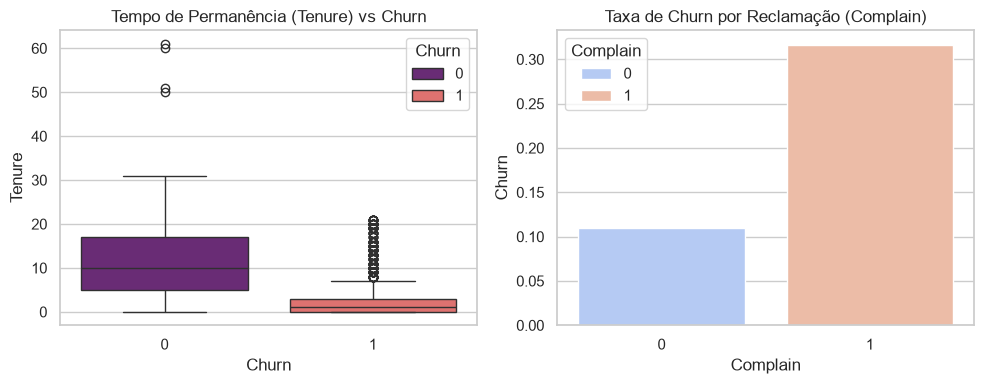


-------



In [33]:
print(f"\n{"-"*7}\n")

# 6.
# -- Gráficos de relacionamento e distribuições
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
print("GRÁFICO 6: Cruzamentos e relações")
print("'Tenure' vs 'Churn', e 'Churn' vs 'Complain'")

# 1. Tenure vs Churn
sns.boxplot(ax=axes[0], data=df, x='Churn', y='Tenure', palette='magma', hue='Churn')
axes[0].set_title('Tempo de Permanência (Tenure) vs Churn')

# 2. Reclamações vs Churn
sns.barplot(ax=axes[1], data=df, x='Complain', y='Churn', palette='coolwarm', errorbar=None, hue='Complain')
axes[1].set_title('Taxa de Churn por Reclamação (Complain)')

plt.tight_layout()
plt.show()

print(f"\n{"-"*7}\n")

## Interpretando a Análise Exploratória e Estratégia de Preparação

*  Vemos que a coluna Churn está desbalanceada, com muitos registros de pessoas que ficam na plataforma **(83%)** e poucos que saiam dela **(17%)**, portanto, um balanceamento de dados deve ser considerado.

*  A taxa de reclamação de clientes que saem é alta, assim como o tempo de permanência é pouco se comparado aos que ficam, indicando que clientes novos tem uma alta probabilidade de sair da plataforma.

*  Cerca de **20.7%** dos clientes atribuíram a nota mínima (1) de satisfação. O cruzamento desses dados com 'Complain' mostra que a insatisfação é um driver direto para o cancelamento.

*  Temos 7 colunas com uma média de **5%** de valores nulos, incluindo colunas importantes como **'Tenure'**, **'DaySinceLastOrder'**, e outliers significativos em **'CashbackAmount'**. Os outliers podem requerer uma atenção mais profunda na etapa de tratamento para evitar criar um viés quando for usar esses dados para treinar um modelo.

*  Analisando as linhas da média e desvio padrão do .describe(), percebemos que boa parte das colunas tem a média acima do desvio padrão, e excluindo casos de colunas binarias como **Churn** e **Complain**, poucas colunas tem uma média proxima do desvio padrão, o que indica alta dispersão. Para deixar tudo normalizado, usar a mediana para todas as colunas com dados faltantes é a melhor opção.

*  A quantidade de cupons usados tem pouca correlação com o tempo de permanência **(Tenure)** e quase nenhuma com a saída do cliente **(Churn)**, mostrando que os cupons usados não necessariamente vão fazer um cliente ficar na plataforma.

A matriz de correlação indica vários aspectos sobre o comportamento dos dados, como:

*  Churn vs. Tenure (-0.35), que é a correlação negativa mais forte, e indica que quanto maior o tempo de permanência, menor a chance de o cliente abandonar a plataforma.

*  CouponUsed vs. OrderCount (0.75) indica multicolinearidade devido a alta correlação que tem, pois quanto mais pedidos um cliente faz, maior a chances dele usar um cupon. Portanto manter ambas pode ser redundânte. OrderCount pode representar melhor o habito de compra do cliente.

*  Tenure vs. CashbackAmount (0.48), tem uma correlação média e sugere que clientes que ficam mais tempo na plataforma, tem maiores chances de acumular valores de cashback.

*  OrderCount vs. DaySinceLastOrder (0.50): Clientes que tem um volume maior de pedidos tem mais chances de realizar pedidos frequentemente, ou os pedidos do cliente estão ligados a sua atividade recente na plataforma.

*  Churn vs. Complain (0.25) mostra a tendência de que clientes que registram reclamações tem uma probabilidade maior de sair da plataforma.

Algumas variáveis como **'HourSpendOnApp'**, **'NumberOfDeviceRegistered'** e **'NumberOfAddress'**, tem correlação proxima de zero com o alvo **'Churn'**, mostrando que elas não explicam muito a desistência do cliente, portanto, a remoção delas durante a fase de treino pode ser considerada.

# Fase 2 e 3: Tratamento e Limpeza dos Dados, e Feature Engineering

Com a nossa análise concluida, vamos agora partir para a etapa de limpeza e tratamento, e criação de novas colunas relevantes (Feature Engineering).

## Tratamento e Limpeza

In [34]:
print(f"{'-'*10} ETAPA 2 e 3: Inicio do Tratamento e Limpeza {'-'*10}")
print("="*65)

# Fazendo uma copia para não modificar o dataframe original
df_tratamento = df.copy()

# ====
# -- 1. Checando valores duplicados
print(f"\n1. Quantidade de duplicados: {df_tratamento.duplicated().sum()}")

# ====
# -- 2. Retirando 'CouponUsed' devido a alta correlação com 'OrderCount' e outras
# colunas menos relevantes
df_tratamento = df_tratamento.drop(columns=['CouponUsed', 'CustomerID', 'NumberOfDeviceRegistered', 'HourSpendOnApp'])

# ====
# -- 3. Tratando Nulos
# Contando os nulos antes do tratamento
print("\n2. Contagem de Nulos (NaN) ANTES do tratamento:")
print(df_tratamento.isna().sum()[df_tratamento.isna().sum() > 0])

# Conforme nossa Análise Exploratória, utilizaremos a mediana para
# diminuir o impacto dos outliers
print("\nTratando nulos...")

# Preenchendo valores vazios com a mediana
colunas_nulos = df_tratamento.columns[df_tratamento.isna().any()].tolist()
for col in colunas_nulos:
  df_tratamento[col] = df_tratamento[col].fillna(df_tratamento[col].median())

print("Valores nulos preenchidos com a mediana.")

# Contando os nulos depois do tratamento
print("\n3. Contagem de Nulos (NaN) DEPOIS do tratamento:")
print(df_tratamento.isna().sum()[df_tratamento.isna().sum() > 0])
print("Esta vazio, portanto, os nulos foram zerados.")

# Verificar se ainda existem nulos
print("\nVerificando valores nulos após imputação:")
print(f"- Forma do dataset: {df_tratamento.shape}")
print(f"- Total de Nulos: {df_tratamento.isnull().sum().sum()}")

# ====
# -- 4. Identificando e tratando outliers
colunas_numericas = ['Tenure', 'WarehouseToHome', 'OrderAmountHikeFromlastYear',
                     'OrderCount', 'DaySinceLastOrder', 'CashbackAmount']

# Dicionário para armazenar os resultados
resultados_outliers = {}

# Iterando sobre as colunas para calcular a porcentagem
for col in colunas_numericas:
    Q1 = df_tratamento[col].quantile(0.25)
    Q3 = df_tratamento[col].quantile(0.75)
    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    # Identifica os valores fora dos limites
    outliers = (df_tratamento[col] < limite_inferior) | (df_tratamento[col] > limite_superior)

    outlier_porcentagem = (outliers.sum() / len(df_tratamento)) * 100
    resultados_outliers[col] = outlier_porcentagem

# Criando um DataFrame para facilitar a ordenação e formatação da saída
df_outliers = pd.DataFrame(list(resultados_outliers.items()), columns=['Coluna', 'Porcentagem (%)'])
df_outliers = df_outliers.sort_values(by='Porcentagem (%)', ascending=False)

print("\n4. Porcentagem de outliers (via IQR) por coluna (ordenado):\n")
# Imprimindo com formatação para manter o espaçamento igual
for index, row in df_outliers.iterrows():
    print(f"{row['Coluna']:<30} {row['Porcentagem (%)']:>6.2f}%")

# OrderCount(12.49%) e CashbackAmount(7.94%) tiveram outliers muito altos,
# portanto, vamos limitar (clipping) o valor desses outliers dessas colunas

print("\nTratando outliers...")
colunas_p_clipping = ['OrderCount', 'CashbackAmount']

for col in colunas_p_clipping:
    Q1 = df_tratamento[col].quantile(0.25)
    Q3 = df_tratamento[col].quantile(0.75)
    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    df_tratamento[col] = df_tratamento[col].clip(lower=limite_inferior, upper=limite_superior)

print("Outliers tratados com sucesso via Clipping.")

# Vamos ver como o tratamento dos outliers modifica o dataframe com .describe(),
# com o foco sendo o valor maximo (max), o terceiro quartil (75%), e a mediana (50%)

print("\nAnalisando as modificações (OrderCount, CashbackAmount):")
display(df_tratamento[colunas_p_clipping].describe())

---------- ETAPA 2 e 3: Inicio do Tratamento e Limpeza ----------

1. Quantidade de duplicados: 0

2. Contagem de Nulos (NaN) ANTES do tratamento:
Tenure                         264
WarehouseToHome                251
OrderAmountHikeFromlastYear    265
OrderCount                     258
DaySinceLastOrder              307
dtype: int64

Tratando nulos...
Valores nulos preenchidos com a mediana.

3. Contagem de Nulos (NaN) DEPOIS do tratamento:
Series([], dtype: int64)
Esta vazio, portanto, os nulos foram zerados.

Verificando valores nulos após imputação:
- Forma do dataset: (5630, 16)
- Total de Nulos: 0

4. Porcentagem de outliers (via IQR) por coluna (ordenado):

OrderCount                      12.49%
CashbackAmount                   7.94%
DaySinceLastOrder                1.10%
OrderAmountHikeFromlastYear      0.59%
Tenure                           0.07%
WarehouseToHome                  0.04%

Tratando outliers...
Outliers tratados com sucesso via Clipping.

Analisando as modificações 

,OrderCount,CashbackAmount
count,5630.000000,5630.000000
mean,2.520604,175.225577
std,1.711109,43.834427
min,1.000000,71.000000
25%,1.000000,146.000000
50%,2.000000,163.000000
75%,3.000000,196.000000
max,6.000000,271.000000


# Feature Engineering

Vamos criar a coluna 'cashback_por_pedido', para ver o valor de cashback de cada pedido.

In [35]:
print(f"{'-'*10} Engenharia de Features {'-'*10}")
print("="*44)

df_tratamento["cashback_por_pedido"] = df_tratamento["CashbackAmount"] / df_tratamento["OrderCount"]
print("\nNova coluna 'cashback_por_pedido' criada.")

display(df_tratamento[['CashbackAmount', 'OrderCount', 'cashback_por_pedido']].head())

---------- Engenharia de Features ----------

Nova coluna 'cashback_por_pedido' criada.


,CashbackAmount,OrderCount,cashback_por_pedido
0,160,1.0,160.0
1,121,1.0,121.0
2,120,1.0,120.0
3,134,1.0,134.0
4,130,1.0,130.0


In [36]:
# Analisando as estatísticas descritivas da nova feature
print("Estatísticas Descritivas: cashback_por_pedido")
display(df_tratamento[['cashback_por_pedido']].describe())

Estatísticas Descritivas: cashback_por_pedido


,cashback_por_pedido
count,5630.000000
mean,96.257738
std,50.480359
min,11.833333
25%,56.000000
50%,87.000000
75%,129.000000
max,271.000000


# Fase 4: Separação, Balanceamento e Escalonamento

Com o tratamento completo, agora vamos preparar os dados para treinar os modelos, com a codificação das colunas categoricas, a separação de treino e teste, o balanceamento da coluna alvo, e o escalonamento (Standard Scaler) dos dados para utilizar eles com o KNN, enquanto a Árvore fica com os dados não escalonados.

In [38]:
print(f"{'-'*10} Etapa 4: Encoding {'-'*10}")
print("="*39)

# -- Encoding
# Visualizar quais colunas não são númericas
print("\nColunas categóricas:")
non_numeric_df = df_tratamento.select_dtypes(exclude=['number'])
display(non_numeric_df.head(2))
print("Tamanho antes da codificação:")
print(f"{" "*2}- Linhas: {df_tratamento.shape[0]}")
print(f"{" "*2}- Colunas: {df_tratamento.shape[1]}")

# Nenhuma das categorias são ordinais (possuem uma ordem), portanto,
# o One Hot Encoding será usado para todos

print("\nCodificando as colunas.")

non_numeric_cols = df_tratamento.select_dtypes(exclude=['number']).columns.tolist()
df_pronto = pd.get_dummies(df_tratamento, columns=non_numeric_cols, drop_first=True)

print("Colunas codificadas!")
display(df_pronto.head(3))
print("Tamanho após a codificação:")
print(f"{" "*2}- Linhas: {df_pronto.shape[0]}")
print(f"{" "*2}- Colunas: {df_pronto.shape[1]}")

---------- Etapa 4: Encoding ----------

Colunas categóricas:


,PreferredLoginDevice,PreferredPaymentMode,Gender,PreferedOrderCat,MaritalStatus
0,Mobile Phone,Debit Card,Female,Laptop & Accessory,Single
1,Phone,UPI,Male,Mobile,Single


Tamanho antes da codificação:
  - Linhas: 5630
  - Colunas: 17

Codificando as colunas.
Colunas codificadas!


,Churn,Tenure,CityTier,WarehouseToHome,SatisfactionScore,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,OrderCount,DaySinceLastOrder,...,PreferredPaymentMode_E wallet,PreferredPaymentMode_UPI,Gender_Male,PreferedOrderCat_Grocery,PreferedOrderCat_Laptop & Accessory,PreferedOrderCat_Mobile,PreferedOrderCat_Mobile Phone,PreferedOrderCat_Others,MaritalStatus_Married,MaritalStatus_Single
0,1,4.0,3,6.0,2,9,1,11.0,1.0,5.0,...,False,False,False,False,True,False,False,False,False,True
1,1,9.0,1,8.0,3,7,1,15.0,1.0,0.0,...,False,True,True,False,False,True,False,False,False,True
2,1,9.0,1,30.0,3,6,1,14.0,1.0,3.0,...,False,False,True,False,False,True,False,False,False,True


Tamanho após a codificação:
  - Linhas: 5630
  - Colunas: 28


In [39]:
non_numeric_df = df_tratamento.select_dtypes(exclude=['number'])

display(non_numeric_df.head())

for col in non_numeric_df:
  display(non_numeric_df[col].value_counts())

,PreferredLoginDevice,PreferredPaymentMode,Gender,PreferedOrderCat,MaritalStatus
0,Mobile Phone,Debit Card,Female,Laptop & Accessory,Single
1,Phone,UPI,Male,Mobile,Single
2,Phone,Debit Card,Male,Mobile,Single
3,Phone,Debit Card,Male,Laptop & Accessory,Single
4,Phone,CC,Male,Mobile,Single


PreferredLoginDevice
Mobile Phone    2765
Computer        1634
Phone           1231
Name: count, dtype: int64

PreferredPaymentMode
Debit Card          2314
Credit Card         1501
E wallet             614
UPI                  414
COD                  365
CC                   273
Cash on Delivery     149
Name: count, dtype: int64

Gender
Male      3384
Female    2246
Name: count, dtype: int64

PreferedOrderCat
Laptop & Accessory    2050
Mobile Phone          1271
Fashion                826
Mobile                 809
Grocery                410
Others                 264
Name: count, dtype: int64

MaritalStatus
Married     2986
Single      1796
Divorced     848
Name: count, dtype: int64

In [40]:
from sklearn.model_selection import train_test_split

print(f"{'-'*10} Divisão de Treino e Teste {'-'*10}")
print("="*47)

# -- Separação de X e Y
print("\nSeparando em treino e teste.")

x = df_pronto.drop(columns=['Churn'])
y = df_pronto['Churn']

# -- Divisão Train Test

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.20, stratify=y, random_state=42)

print(f"\nDados de Treino: {x_train.shape[0]}")
print(f"Dados de Teste: {x_test.shape[0]}")

---------- Divisão de Treino e Teste ----------

Separando em treino e teste.

Dados de Treino: 4504
Dados de Teste: 1126


In [41]:
from sklearn.preprocessing import StandardScaler

print(f"{'-'*10} Escalonamento {'-'*10}")
print("="*35)

# Separamos dois dataframes, um escalonado para usar com KNN, e outro
# não escalonado para usar com Árvore de Decisão

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

# x_train será usado para Árvore de Decisão, enquanto
# x_train_scaled será usado para KNN

print("\nDados foram escalonados.")

---------- Escalonamento ----------

Dados foram escalonados.


O modelo de Árvore de Decisão foi treinado utilizando os dados originais (não escalonados), e isso se deve à natureza matemática do algoritmo:

Eles realizam partições no espaço de atributos através de cortes monotônicos perpendiculares aos eixos. A escolha do ponto de corte (split) em um nó depende apenas da ordem relativa (relação monotônica) dos valores daquela variável específica, buscando maximizar a pureza (via Critério de Gini ou Entropia). Como a decisão de divisão em um nó depende apenas da ordem relativa dos valores daquela feature específica e não da magnitude ou distância global, a escala das variáveis não altera o resultado do modelo. Portanto, a Árvore de Decisão dispensa o uso de StandardScaler.

In [42]:
from imblearn.over_sampling import SMOTE

print(f"{'-'*10} Balanceamento {'-'*10}")
print("="*35)

smote = SMOTE(random_state=42)

# Balanceando de acordo com o modelo
# KNN
x_train_scaled_final, y_train_scaled_final = smote.fit_resample(x_train_scaled, y_train)
# Árvore de Decisão
x_train_final, y_train_final = smote.fit_resample(x_train, y_train)

print("\nDados foram balanceados.")

---------- Balanceamento ----------

Dados foram balanceados.


In [43]:
print(f" {'-'*10} Verificação de Balanceamento (SMOTE) {'-'*10} ")

# Verificação para os dados de Árvore de Decisão
print("1. Distribuição de Churn (Treino) - ANTES do SMOTE:")
print(y_train.value_counts())

print("\n2. Distribuição de Churn (Treino) - DEPOIS do SMOTE:")
print(y_train_final.value_counts())

print("\n" + "="*50)

# Verificação para os dados de KNN (Escalonados)
print("3. Distribuição de Churn (Treino Escalonado) - DEPOIS do SMOTE:")
print(y_train_scaled_final.value_counts())

 ---------- Verificação de Balanceamento (SMOTE) ---------- 
1. Distribuição de Churn (Treino) - ANTES do SMOTE:
Churn
0    3746
1     758
Name: count, dtype: int64

2. Distribuição de Churn (Treino) - DEPOIS do SMOTE:
Churn
0    3746
1    3746
Name: count, dtype: int64

3. Distribuição de Churn (Treino Escalonado) - DEPOIS do SMOTE:
Churn
0    3746
1    3746
Name: count, dtype: int64


# Fase 5: Modelagem e Validação

In [44]:
from sklearn.metrics import accuracy_score, classification_report

## KNN

In [45]:
from sklearn.neighbors import KNeighborsClassifier

print(f"{'-'*10} Etapa 5: Teste de Modelos {'-'*10}")
print("="*47)
print(f'\n{'-'*5}/== KNN')

# Para testar todos os valores de K pedidos, faremos um loop
# para comparar a pontuação da acuracia, onde o maior será selecionado

k_valores = [3, 5, 7, 9, 11, 13]

for k in k_valores:

  print(f"\nKNN com K = {k}")
  knn = KNeighborsClassifier(n_neighbors=k, metric='euclidean')
  knn.fit(x_train_scaled_final, y_train_scaled_final)

  y_pred_knn = knn.predict(x_test_scaled)

  print(f"Acurácia: {accuracy_score(y_test, y_pred_knn) * 100:.2f}%")
  print("\nRelatório:")
  print(classification_report(y_test, y_pred_knn))

  print("-----\n")


---------- Etapa 5: Teste de Modelos ----------

-----/== KNN

KNN com K = 3
Acurácia: 90.76%

Relatório:
              precision    recall  f1-score   support

           0       0.98      0.91      0.94       936
           1       0.67      0.91      0.77       190

    accuracy                           0.91      1126
   macro avg       0.82      0.91      0.86      1126
weighted avg       0.93      0.91      0.91      1126

-----


KNN com K = 5
Acurácia: 86.68%

Relatório:
              precision    recall  f1-score   support

           0       0.98      0.86      0.91       936
           1       0.56      0.92      0.70       190

    accuracy                           0.87      1126
   macro avg       0.77      0.89      0.81      1126
weighted avg       0.91      0.87      0.88      1126

-----


KNN com K = 7
Acurácia: 82.86%

Relatório:
              precision    recall  f1-score   support

           0       0.97      0.82      0.89       936
           1       0.50      

In [46]:
from sklearn.model_selection import cross_val_score

print(f" {'-'*10} Validação Cruzada (KNN) {'-'*10} ")
print("="*50)

# Utilizando o K=5 que foi identificado como uma boa escolha
knn_cv = KNeighborsClassifier(n_neighbors=5, metric='euclidean')

# Executando a validação cruzada (5 folds)
# Usamos x_train_scaled_final e y_train_scaled_final que já passaram por SMOTE e Scaling
cv_scores = cross_val_score(knn_cv, x_train_scaled_final, y_train_scaled_final, cv=5)

print(f"\nScores de cada fold: {cv_scores}")
print(f"Acurácia média: {cv_scores.mean() * 100:.2f}%")
print(f"Desvio padrão: {cv_scores.std() * 100:.2f}%")

 ---------- Validação Cruzada (KNN) ---------- 

Scores de cada fold: [0.90460307 0.91194129 0.92456609 0.91455274 0.92323097]
Acurácia média: 91.58%
Desvio padrão: 0.74%


### Diagnóstico de Overfitting no KNN

Vamos avaliar a performance tanto no treino quanto no teste para identificar se o modelo está sofrendo de overfitting (sobreajuste).

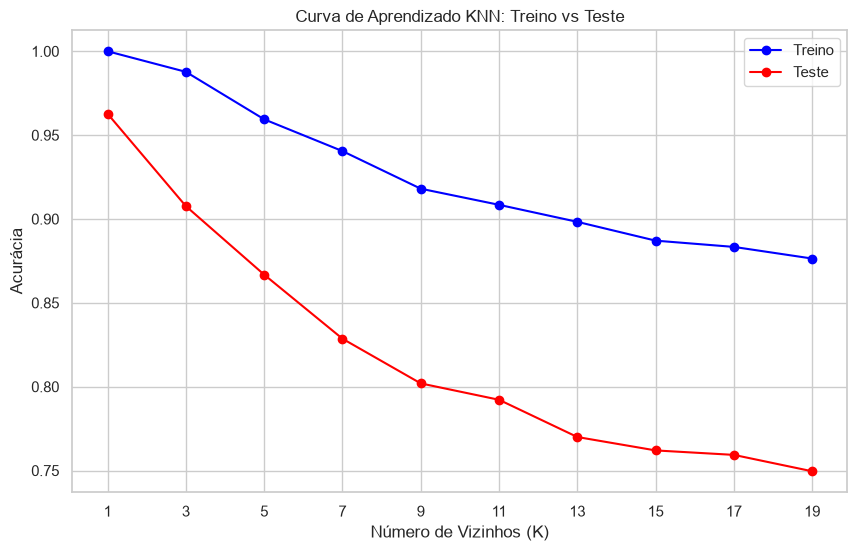

In [47]:
import matplotlib.pyplot as plt

train_scores = []
test_scores = []
k_valores = range(1, 21, 2) # Testando de 1 a 19

for k in k_valores:
    knn_diag = KNeighborsClassifier(n_neighbors=k, metric='euclidean')
    knn_diag.fit(x_train_scaled_final, y_train_scaled_final)

    # Score no treino
    y_pred_train = knn_diag.predict(x_train_scaled_final)
    train_acc = accuracy_score(y_train_scaled_final, y_pred_train)
    train_scores.append(train_acc)

    # Score no teste
    y_pred_test = knn_diag.predict(x_test_scaled)
    test_acc = accuracy_score(y_test, y_pred_test)
    test_scores.append(test_acc)

# Plotando o gráfico de diagnóstico
plt.figure(figsize=(10, 6))
plt.plot(k_valores, train_scores, '-o', label='Treino', color='blue')
plt.plot(k_valores, test_scores, '-o', label='Teste', color='red')
plt.title('Curva de Aprendizado KNN: Treino vs Teste')
plt.xlabel('Número de Vizinhos (K)')
plt.ylabel('Acurácia')
plt.xticks(k_valores)
plt.legend()
plt.grid(True)
plt.show()

### Busca pelo K Ideal (Método do Cotovelo e F1-Score)

Vamos analisar a taxa de erro e o F1-Score para determinar qual K oferece o melhor equilíbrio entre viés e variância.

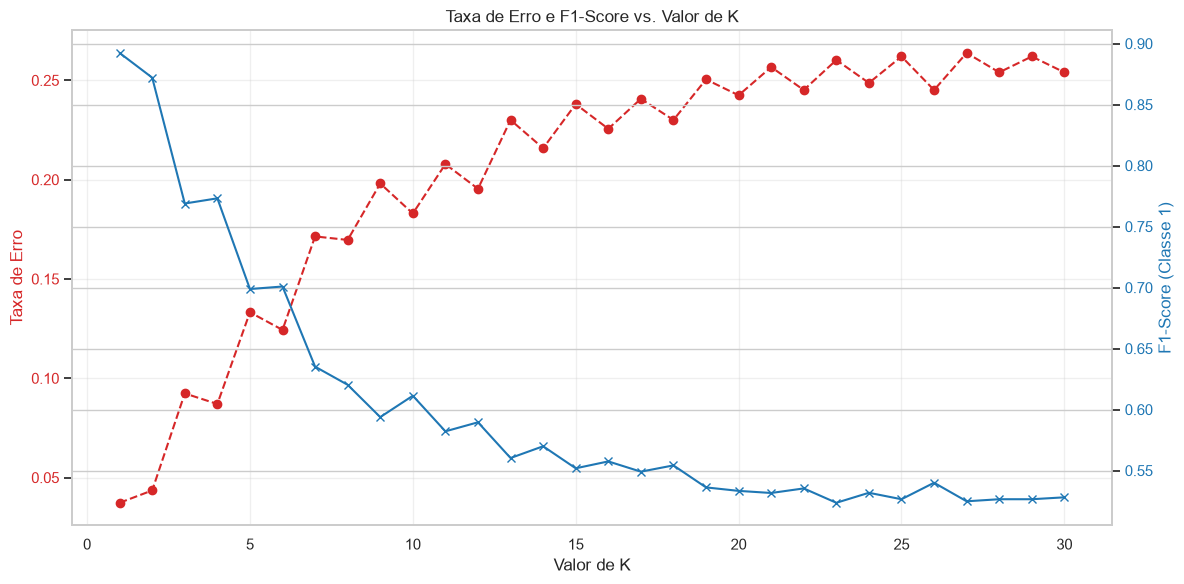

In [48]:
from sklearn.metrics import f1_score

error_rate = []
f1_scores = []
k_range = range(1, 31)

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k, metric='euclidean')
    knn.fit(x_train_scaled_final, y_train_scaled_final)
    pred_i = knn.predict(x_test_scaled)

    error_rate.append(np.mean(pred_i != y_test))
    f1_scores.append(f1_score(y_test, pred_i))

# Plotagem dos resultados
fig, ax1 = plt.subplots(figsize=(12, 6))

color = 'tab:red'
ax1.set_xlabel('Valor de K')
ax1.set_ylabel('Taxa de Erro', color=color)
ax1.plot(k_range, error_rate, color=color, linestyle='dashed', marker='o', label='Erro')
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = 'tab:blue'
ax2.set_ylabel('F1-Score (Classe 1)', color=color)
ax2.plot(k_range, f1_scores, color=color, marker='x', label='F1-Score')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Taxa de Erro e F1-Score vs. Valor de K')
ax1.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

ideal_k_error = k_range[np.argmin(error_rate)]
ideal_k_f1 = k_range[np.argmax(f1_scores)]

In [49]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Treinando o modelo final com K=5
knn_final = KNeighborsClassifier(n_neighbors=5, metric='euclidean')
knn_final.fit(x_train_scaled_final, y_train_scaled_final)

# Previsões no conjunto de teste
y_pred_final = knn_final.predict(x_test_scaled)

# Cálculo das métricas
precision = precision_score(y_test, y_pred_final)
recall = recall_score(y_test, y_pred_final)
f1 = f1_score(y_test, y_pred_final)

print(f" {'-'*10} Métricas Detalhadas: KNN (K=5) {'-'*10} ")
print(f"\nPrecisão (Precision): {precision * 100:.2f}%")
print(f"Revocação (Recall):   {recall * 100:.2f}%")
print(f"F1-Score:             {f1 * 100:.2f}%")
print()
print("="*50)
print("\nRelatório Completo de Classificação:")
print(classification_report(y_test, y_pred_final))

 ---------- Métricas Detalhadas: KNN (K=5) ---------- 

Precisão (Precision): 56.49%
Revocação (Recall):   91.58%
F1-Score:             69.88%


Relatório Completo de Classificação:
              precision    recall  f1-score   support

           0       0.98      0.86      0.91       936
           1       0.56      0.92      0.70       190

    accuracy                           0.87      1126
   macro avg       0.77      0.89      0.81      1126
weighted avg       0.91      0.87      0.88      1126



Com base nos resultados, e nos gráficos, podemos concluir que o **K = 5** é a melhor escolha para o relatório final, pois:

1.   Temos uma taxa de erro mais estável e um F1-Score equilibrado, e conseguiu generalizar melhor o dataset se comparado com outros valores.

2.   Teve o melhor equilíbrio entre a sensibilidade (Recall) e a precisão.

## Árvore de Decisão

In [50]:
from sklearn.tree import DecisionTreeClassifier

print(f'\n{'-'*5}/== Árvore de Decisão')

# Faremos outro loop para testar varios hiperparâmetros
# para a árvore de decisão

profundidade_valores = [3, 5, 7, 9, None]

for k in profundidade_valores:

  print(f"\nÁrvore de Decisão com profundidade = {k}")

  arvore = DecisionTreeClassifier(max_depth=k, random_state=42,
                                  criterion='gini'
  )
  arvore.fit(x_train_final, y_train_final)

  y_pred_arvore = arvore.predict(x_test)

  print(f"Acurácia: {accuracy_score(y_test, y_pred_arvore) * 100:.2f}%")
  print("\nRelatório:")
  print(classification_report(y_test, y_pred_arvore))

  print("-----\n")


-----/== Árvore de Decisão

Árvore de Decisão com profundidade = 3
Acurácia: 84.19%

Relatório:
              precision    recall  f1-score   support

           0       0.93      0.87      0.90       936
           1       0.52      0.69      0.60       190

    accuracy                           0.84      1126
   macro avg       0.73      0.78      0.75      1126
weighted avg       0.86      0.84      0.85      1126

-----


Árvore de Decisão com profundidade = 5
Acurácia: 86.41%

Relatório:
              precision    recall  f1-score   support

           0       0.92      0.91      0.92       936
           1       0.59      0.63      0.61       190

    accuracy                           0.86      1126
   macro avg       0.76      0.77      0.76      1126
weighted avg       0.87      0.86      0.87      1126

-----


Árvore de Decisão com profundidade = 7
Acurácia: 87.74%

Relatório:
              precision    recall  f1-score   support

           0       0.94      0.92      0.9

In [51]:
from sklearn.model_selection import cross_val_score

print(f" {'-'*10} Validação Cruzada (Árvore de Decisão) {'-'*10} ")
print("="*60)

# Utilizando o K=9 que foi identificado como uma boa escolha
arvore_cv = DecisionTreeClassifier(max_depth=9, random_state=42)

# Executando a validação cruzada (5 folds)
cv_scores = cross_val_score(arvore_cv, x_train_final, y_train_final, cv=5)

print(f"\nScores de cada fold: {cv_scores}")
print(f"Acurácia média: {cv_scores.mean() * 100:.2f}%")
print(f"Desvio padrão: {cv_scores.std() * 100:.2f}%")

 ---------- Validação Cruzada (Árvore de Decisão) ---------- 

Scores de cada fold: [0.83522348 0.89993329 0.91455274 0.91121495 0.90720961]
Acurácia média: 89.36%
Desvio padrão: 2.96%


### Diagnóstico de Overfitting: Árvore de Decisão

Vamos visualizar como a profundidade da árvore afeta a performance em ambos os conjuntos de dados.

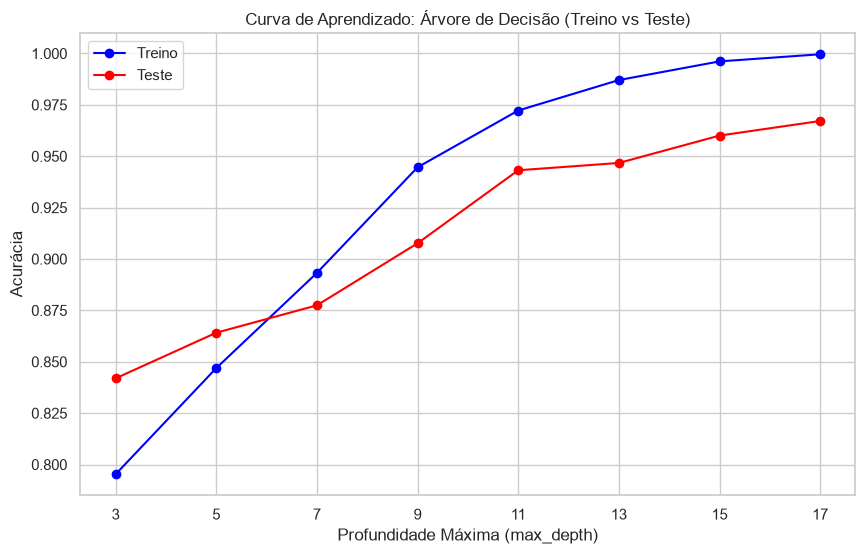

In [53]:
train_scores_dt = []
test_scores_dt = []

# Testando profundidades de 3 a 17
profundidades = range(3, 19, 2)

for d in profundidades:
    dt_diag = DecisionTreeClassifier(max_depth=d, random_state=42)
    dt_diag.fit(x_train_final, y_train_final)

    # Acurácia no Treino
    train_acc = accuracy_score(y_train_final, dt_diag.predict(x_train_final))
    train_scores_dt.append(train_acc)

    # Acurácia no Teste
    test_acc = accuracy_score(y_test, dt_diag.predict(x_test))
    test_scores_dt.append(test_acc)

# Plotando os resultados
plt.figure(figsize=(10, 6))
plt.plot(profundidades, train_scores_dt, '-o', label='Treino', color='blue')
plt.plot(profundidades, test_scores_dt, '-o', label='Teste', color='red')
plt.title('Curva de Aprendizado: Árvore de Decisão (Treino vs Teste)')
plt.xlabel('Profundidade Máxima (max_depth)')
plt.ylabel('Acurácia')
plt.xticks(profundidades)
plt.legend()
plt.grid(True)
plt.show()

A partir da profundidade 9, os valores de treino passam a ter um aumento menor até se estabilizar na profundidade 15, portanto, vamos usar a profundidade 9 como a melhor escolha para a árvore.

In [54]:
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report

# Treinando o modelo final com a profundidade ideal (max_depth=9)
arvore_final = DecisionTreeClassifier(max_depth=9, random_state=42)
arvore_final.fit(x_train_final, y_train_final)

# Previsões no conjunto de teste
y_pred_final = arvore_final.predict(x_test)

# Cálculo das métricas
precision = precision_score(y_test, y_pred_final)
recall = recall_score(y_test, y_pred_final)
f1 = f1_score(y_test, y_pred_final)

print(f" {'-'*10} Métricas Detalhadas: Árvore de Decisão (max_depth=9) {'-'*10} ")
print(f"\nPrecisão (Precision): {precision * 100:.2f}%")
print(f"Revocação (Recall):   {recall * 100:.2f}%")
print(f"F1-Score:             {f1 * 100:.2f}%")
print()
print("="*50)
print("\nRelatório Completo de Classificação:")
print(classification_report(y_test, y_pred_final))

 ---------- Métricas Detalhadas: Árvore de Decisão (max_depth=9) ---------- 

Precisão (Precision): 69.37%
Revocação (Recall):   81.05%
F1-Score:             74.76%


Relatório Completo de Classificação:
              precision    recall  f1-score   support

           0       0.96      0.93      0.94       936
           1       0.69      0.81      0.75       190

    accuracy                           0.91      1126
   macro avg       0.83      0.87      0.85      1126
weighted avg       0.92      0.91      0.91      1126



## Comparação e Visualização da Acurácia

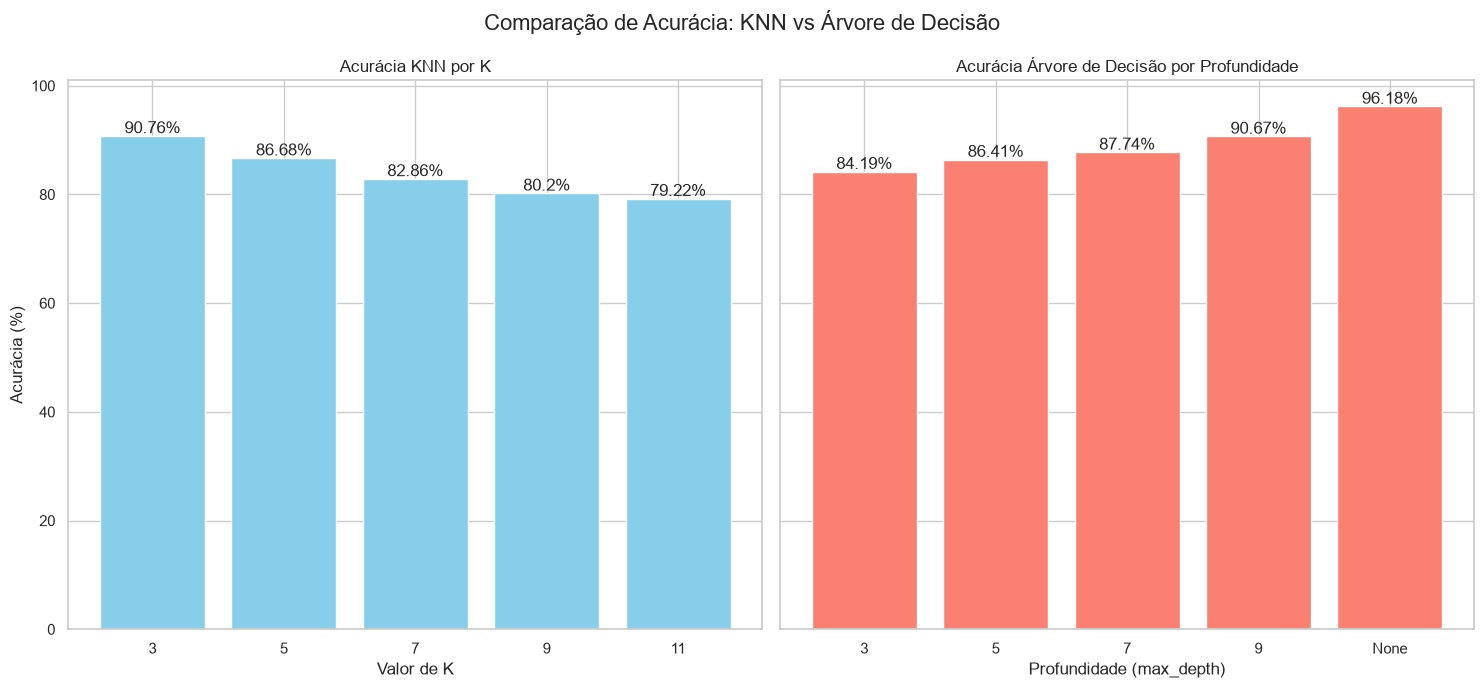

In [55]:
import matplotlib.pyplot as plt
import pandas as pd

# Resultados coletados das execuções anteriores
params_knn = [3, 5, 7, 9, 11]
acc_knn = [90.76, 86.68, 82.86, 80.20, 79.22]

params_tree = ['3', '5', '7', '9', 'None']
acc_tree = [84.19, 86.41, 87.74, 90.67, 96.18]

# Criando o comparativo
fig, ax = plt.subplots(1, 2, figsize=(15, 7), sharey=True)

# Plot KNN
ax[0].bar([str(k) for k in params_knn], acc_knn, color='skyblue')
ax[0].set_title('Acurácia KNN por K')
ax[0].set_xlabel('Valor de K')
ax[0].set_ylabel('Acurácia (%)')
for i, v in enumerate(acc_knn):
    ax[0].text(i, v + 0.5, f"{v}%", ha='center')

# Plot Árvore
ax[1].bar(params_tree, acc_tree, color='salmon')
ax[1].set_title('Acurácia Árvore de Decisão por Profundidade')
ax[1].set_xlabel('Profundidade (max_depth)')
for i, v in enumerate(acc_tree):
    ax[1].text(i, v + 0.5, f"{v}%", ha='center')

plt.suptitle('Comparação de Acurácia: KNN vs Árvore de Decisão', fontsize=16)
plt.tight_layout()
plt.show()

In [57]:
import pandas as pd

# 1. Preparação dos dados do KNN (K=3, 5, 7, 9, 11)
params_knn = [3, 5, 7, 9, 11]
acc_knn_test = [90.76, 86.68, 82.86, 80.20, 79.22]
acc_knn_train = [98.77, 95.94, 94.05, 91.80, 90.84]

df_knn = pd.DataFrame({
    'Modelo': 'KNN',
    'Parâmetro': [f'K={k}' for k in params_knn],
    'Treino (%)': acc_knn_train,
    'Teste (%)': acc_knn_test
})

# 2. Preparação dos dados da Árvore (Depth=3, 5, 7, 9, None)
params_tree = ['3', '5', '7', '9', 'None']
acc_tree_test = [84.19, 86.41, 87.74, 90.67, 96.18]
acc_tree_train = [79.52, 84.69, 89.47, 94.43, 99.99]

df_tree = pd.DataFrame({
    'Modelo': 'Árvore de Decisão',
    'Parâmetro': [f'Depth={d}' for d in params_tree],
    'Treino (%)': acc_tree_train,
    'Teste (%)': acc_tree_test
})

# 3. Consolidação da Tabela Final
df_comparativo = pd.concat([df_knn, df_tree], ignore_index=True)

# 4. Cálculo da Diferença Absoluta entre Treino e Teste (Indicador de Overfitting)
df_comparativo['Dif. Treino-Teste (Abs)'] = abs(df_comparativo['Treino (%)'] - df_comparativo['Teste (%)']).round(2)

print("Tabela Comparativa: Diagnóstico de Performance e Generalização")
display(df_comparativo)

Tabela Comparativa: Diagnóstico de Performance e Generalização


,Modelo,Parâmetro,Treino (%),Teste (%),Dif. Treino-Teste (Abs)
0,KNN,K=3,98.77,90.76,8.01
1,KNN,K=5,95.94,86.68,9.26
2,KNN,K=7,94.05,82.86,11.19
3,KNN,K=9,91.80,80.20,11.60
4,KNN,K=11,90.84,79.22,11.62
5,Árvore de Decisão,Depth=3,79.52,84.19,4.67
6,Árvore de Decisão,Depth=5,84.69,86.41,1.72
7,Árvore de Decisão,Depth=7,89.47,87.74,1.73
8,Árvore de Decisão,Depth=9,94.43,90.67,3.76
9,Árvore de Decisão,Depth=None,99.99,96.18,3.81


# Fase 6: Avaliação e Veredito de Negócios

Avaliaremos agora, as configurações selecionadas para o KNN **(K = 5)** e a Árvore de Decisão **(max_depth = 9)**, utilizando:

*   Relatório (Classification Report)
*   Matriz de Confusão
*   Número de Falsos Positivos
*   Número de Falsos Negativos

Com base nessa análise, assim podemos ter um veredito final de como esses modelos podem impactar no negócio, qual modelo se sairia melhor para descobrir clientes que tem a tendência de abandonar a plataforma, e qual seria a melhor decisão para se fazer com o uso do modelo selecionado.

In [58]:
# Treinando novamente os modelos e fazendo as predições

print(f"{'-'*10} Etapa 6: Avaliação Final {'-'*10}")
print("="*47)

# -- KNN (k=5)
knn_final = KNeighborsClassifier(n_neighbors=5, metric='euclidean')
knn_final.fit(x_train_scaled_final, y_train_scaled_final)

y_pred_knn_final = knn_final.predict(x_test_scaled)

print("\nKNN final treinado.")

# -- Arvore de Decisão (max_depth = 9)
arvore_final = DecisionTreeClassifier(max_depth=9, random_state=42)
arvore_final.fit(x_train_final, y_train_final)

y_pred_arvore_final = arvore_final.predict(x_test)

print("Árvore de Decisão final treinado.")

---------- Etapa 6: Avaliação Final ----------

KNN final treinado.
Árvore de Decisão final treinado.


In [59]:
# Relatorio KNN

print("Relatório Final de Classificação - KNN:\n")
print(classification_report(y_test, y_pred_knn_final,
                            target_names=['Ficou - 0', 'Saiu - 1']))

Relatório Final de Classificação - KNN:

              precision    recall  f1-score   support

   Ficou - 0       0.98      0.86      0.91       936
    Saiu - 1       0.56      0.92      0.70       190

    accuracy                           0.87      1126
   macro avg       0.77      0.89      0.81      1126
weighted avg       0.91      0.87      0.88      1126



In [61]:
# Relatorio Arvore de Decisão

print("Relatório Final de Classificação - Árvore de Decisão:\n")
print(classification_report(y_test, y_pred_arvore_final,
                            target_names=['Ficou - 0', 'Saiu - 1']))

Relatório Final de Classificação - Árvore de Decisão:

              precision    recall  f1-score   support

   Ficou - 0       0.96      0.93      0.94       936
    Saiu - 1       0.69      0.81      0.75       190

    accuracy                           0.91      1126
   macro avg       0.83      0.87      0.85      1126
weighted avg       0.92      0.91      0.91      1126



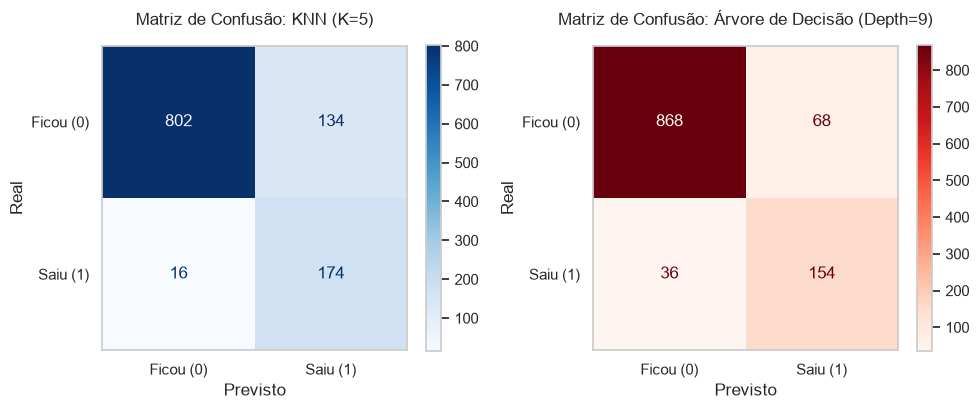

In [62]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# 1. Matriz de Confusão - KNN
cm_knn = confusion_matrix(y_test, y_pred_knn_final)
disp_knn = ConfusionMatrixDisplay(confusion_matrix=cm_knn, display_labels=['Ficou (0)', 'Saiu (1)'])
disp_knn.plot(ax=axes[0], cmap='Blues', values_format='d')
axes[0].set_title('Matriz de Confusão: KNN (K=5)', fontsize=12, pad=15)
axes[0].grid(False)
axes[0].set_xlabel('Previsto')
axes[0].set_ylabel('Real')

# 2. Matriz de Confusão - Árvore de Decisão
cm_arvore = confusion_matrix(y_test, y_pred_arvore_final)
disp_arvore = ConfusionMatrixDisplay(confusion_matrix=cm_arvore, display_labels=['Ficou (0)', 'Saiu (1)'])
disp_arvore.plot(ax=axes[1], cmap='Reds', values_format='d')
axes[1].set_title('Matriz de Confusão: Árvore de Decisão (Depth=9)', fontsize=12, pad=15)
axes[1].grid(False)
axes[1].set_xlabel('Previsto')
axes[1].set_ylabel('Real')

plt.tight_layout()
plt.show()

In [63]:
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, confusion_matrix

# Coletando métricas do KNN (K=5)
accuracy_knn = accuracy_score(y_test, y_pred_knn_final)
precision_knn = precision_score(y_test, y_pred_knn_final)
recall_knn = recall_score(y_test, y_pred_knn_final)
f1_knn = f1_score(y_test, y_pred_knn_final)
tn_knn, fp_knn, fn_knn, tp_knn = confusion_matrix(y_test, y_pred_knn_final).ravel()

# Coletando métricas da Árvore (Depth=9)
accuracy_tree = accuracy_score(y_test, y_pred_arvore_final)
precision_tree = precision_score(y_test, y_pred_arvore_final)
recall_tree = recall_score(y_test, y_pred_arvore_final)
f1_tree = f1_score(y_test, y_pred_arvore_final)
tn_tree, fp_tree, fn_tree, tp_tree = confusion_matrix(y_test, y_pred_arvore_final).ravel()

# Criando o DataFrame comparativo
data = {
    'Métrica': [
        'Acurácia Global',
        'Precisão (Classe 1)',
        'Recall (Classe 1)',
        'F1-Score (Classe 1)',
        'Falsos Positivos (Ficou, previsto como Saiu)',
        'Falsos Negativos (Saiu, previsto como Ficou)',
        'Verdadeiros Positivos (Acertos Saiu)',
        'Verdadeiros Negativos (Acertos Ficou)'
    ],
    'KNN (K=5)': [
        f'{accuracy_knn:.2%}',
        f'{precision_knn:.2%}',
        f'{recall_knn:.2%}',
        f'{f1_knn:.2%}',
        fp_knn,
        fn_knn,
        tp_knn,
        tn_knn
    ],
    'Árvore de Decisão (Depth=9)': [
        f'{accuracy_tree:.2%}',
        f'{precision_tree:.2%}',
        f'{recall_tree:.2%}',
        f'{f1_tree:.2%}',
        fp_tree,
        fn_tree,
        tp_tree,
        tn_tree
    ]
}

df_performance_final = pd.DataFrame(data)

print("Tabela Comparativa de Performance: KNN vs. Árvore de Decisão")
display(df_performance_final)

Tabela Comparativa de Performance: KNN vs. Árvore de Decisão


,Métrica,KNN (K=5),Árvore de Decisão (Depth=9)
0,Acurácia Global,86.68%,90.76%
1,Precisão (Classe 1),56.49%,69.37%
2,Recall (Classe 1),91.58%,81.05%
3,F1-Score (Classe 1),69.88%,74.76%
4,"Falsos Positivos (Ficou, previsto como Saiu)",134,68
5,"Falsos Negativos (Saiu, previsto como Ficou)",16,36
6,Verdadeiros Positivos (Acertos Saiu),174,154
7,Verdadeiros Negativos (Acertos Ficou),802,868


## Analisando a Matriz de Confusão e os Falsos Positivos e Negativos

### Contexto do Negócio e o Peso dos Erros

Antes de analisar os resultados da matriz de confusão, precisamos entender o contexto do negócio. Estamos tentando prever quais clientes de uma plataforma de e-commerce tem mais probabilidade de sair dela, seja por um motivo ou outro.

Nesse problema, precisamos levar em consideração o impacto e custo que será gerado para a plataforma para manter um cliente propenso a sair.

No nosso contexto de e-commerce junto com Machine Learning e matrizes de confusão, a classe de interesse mapeada como **1 (Positivo)** é o evento que queremos prever, ou seja, o **Churn (Clientes que saem)**. Portanto, o **Verdadeiro Positivo (TP)** representa os clientes que saíram e o modelo acertou. O **Verdadeiro Negativo (TN)** representa os clientes que ficaram (Classe 0) e o modelo também acertou.

O **Falso Positivo** são clientes que ficam na plataforma, mas o modelo previu que eles vão sair. Nesse caso, clientes que ficam podem receber **incentivos** (cupons de desconto) sem que eles realmente precisam, o que pode gerar um prejuízo dependo do custo para realizar esses incentivos, além desses incentivos não estar chegando no público alvo (clientes propensos a sair).

O **Falso Negativo** são os clientes que saem da plataforma, mas o modelo prevê eles como clientes que ficam na plataforma. Se **custo de retenção** for alto, perder um cliente pode gerar um prejuízo considerável para o negócio, além da perda de vendas que poderia obter com esse cliente, junto com os custos e recursos que foram usados para manter o cliente antes da saída.

Nesse caso, para saber qual deles seria mais prejudicial para o negócio, é necessário saber quais são os custos para manter um cliente na plataforma, e os custos para dar incentivos aos clientes.

### Comparação de Métricas e Erros dos Modelos

A Árvore de Decisão obteve a maior **Acurácia (90.76%)**, assim como a maior **Precisão (69.37%)** e **F1-Score (74.76%)** dos dois modelos, e teve o menor numero de **Falsos Positivos**, com **68** casos, se comparado ao KNN que teve **134** **Falsos Positivos**, *mostrando* que a Árvore de Decisão conseguiu classificar bem clientes que ficam na plataforma.

No entanto, o KNN, apesar ter uma *Precisão* **(56.49%)** e *F1-Score* **(69.88%)** **menor** do que a Árvore de Decisão, o **Recall** da Classe 1 (clientes que sairam) foi maior com **91.58%** em comparação aos **81.05%** da Árvore de Decisão. Isso mostra que o KNN tem uma capacidade melhor de corretamente identificar clientes que vão sair, e teve **16** *Falsos Negativos*, muito menor do que os **36** *Falsos Negativos* da Árvore de Decisão.

## Veredito Final para o Negócio

A escolha do melhor modelo não depende apenas de qual tem a maior acurácia, mas sim de **quanto custa para a empresa aplicar cada estratégia**. No e-commerce, manter um cliente antigo costuma ser muito mais barato do que gastar dinheiro com propagandas para conseguir um cliente novo.

Olhando para os erros de cada modelo, temos dois caminhos que a empresa pode seguir:

### Cenário 1: Foco em Salvar o Máximo de Clientes
*   **Modelo:** **KNN (K=5)**
*   **Por que usar:** Ele teve um **Recall de 91,58%**. Isso significa que ele é excelente em encontrar quase todo mundo que está pensando em sair da plataforma, deixando escapar apenas **16 pessoas** (Falsos Negativos).
*   **Quando usar:** É a escolha certa se a empresa tiver orçamento para dar muitos cupons ou bônus de cashback (usando a coluna `cashback_por_pedido` que criamos). Como o KNN erra mais ao achar que clientes satisfeitos vão sair (134 Falsos Positivos), a empresa vai acabar gastando cupons com quem não precisava. Mas o gasto vale a pena porque você evita perder quase todos os clientes que realmente iam embora.

### Cenário 2: Foco em Economizar Recursos e Evitar Desperdício
*   **Modelo:** **Árvore de Decisão (Profundidade=9)**
*   **Por que usar:** Este modelo teve uma **Precisão de 69.37%** e errou muito menos ao indicar quem ia sair, gerando apenas **68 Falsos Positivos** (menos da metade do KNN).
*   **Quando usar:** É a melhor escolha se a empresa estiver com pouco dinheiro para investir em campanhas de retenção. A Árvore de Decisão garante que os cupons ou ligações de suporte sejam enviados quase que exclusivamente para as pessoas certas. O ponto negativo é que ela deixa passar **36 clientes** que vão acabar saindo sem receber nenhuma oferta (Falsos Negativos), um número muito maior do que se comparado com o KNN.

### Conclusão do Projeto
Se o custo para dar descontos ou cashback for baixo, o **KNN (K=5)** é o melhor modelo para o e-commerce por salvar mais clientes. Se o orçamento do setor de marketing for muito apertado, a **Árvore de Decisão (max_depth=9)** se torna a melhor opção por ser mais econômica e precisa.